## Figure S3A. Prophage circularization by completeness following mitomycin C treatment

### Setup and run geNomad, CheckV, and mVIRs

In [ ]:
%%bash
### Run mVIRs analysis
# the following shell script was used on each MMC sample in the mvirs_samplesheet.csv

# run geNomad on complete genome assemblies
genomad \
    end-to-end \
    ${complete_genome_fasta} \
    ./ \
    genomad_db \
    --threads 8 \
    --relaxed \
    --splits 5

gzip -c *_summary/*_virus.fna > genomad/mvirs/${sample}_genome/${sample}_genome_virus.fna.gz
mv *_summary/*_virus_summary.tsv genomad/mvirs/${sample}_genome/${sample}_genome_virus_summary.tsv

# run checkv on complete genome assemblies
checkv \
    end_to_end \
    -t 8 \
    -d checkv-db-v1.5 \
    genomad/mvirs/${sample}_genome/${sample}_genome_virus.fna.gz \
    ${sample}

gzip -c ${sample}/completeness.tsv > checkv/mvirs/${sample}_genome_completeness.tsv.gz

# download reads
xsra dump \
    ${acc} \
    --full-quality \
    --outdir . \
    --split \
    --prefix ${acc}_ \
    --compression g \
    --threads 4 \

if ls ${acc}_1.fq.gz 1> /dev/null 2>&1; then
    mv ${acc}_0.fq.gz ${sample}_R1.fastq.gz
    mv ${acc}_1.fq.gz ${sample}_R2.fastq.gz
    rm -rf ${acc}_*.fq.gz || true
else
    echo "No paired-end reads found for ${acc}, skipping"
    rm -rf ${acc}_*.fq.gz || true
    continue
fi

# rename fastqs and ensure all reads are paired
seqkit replace \
    --pattern "\.[01]$" \
    --replacement "\.${sample}" \
    ${sample}_R1.fastq.gz \
    --out-file ${sample}_R1.rename.fastq.gz

rm -rf ${sample}_R1.fastq.gz

seqkit replace \
    --pattern "\.[01]$" \
    --replacement "\.${sample}" \
    ${sample}_R2.fastq.gz \
    --out-file ${sample}_R2.rename.fastq.gz

rm -rf ${sample}_R2.fastq.gz

seqkit pair \
    --read1 ${sample}_R1.rename.fastq.gz \
    --read2 ${sample}_R2.rename.fastq.gz \
    --out-dir .

rm -rf ${sample}_R1.rename.fastq.gz ${sample}_R2.rename.fastq.gz

# run fastp on reads within a biosample
fastp \
    --in1 ${sample}_R1.rename.paired.fastq.gz \
    --in2 ${sample}_R2.rename.paired.fastq.gz \
    --out1 ${sample}_R1.fastp.fastq.gz \
    --out2 ${sample}_R2.fastp.fastq.gz \
    --json ${sample}.fastp.json \
    --html ${sample}.fastp.html \
    --thread 4 \
    --detect_adapter_for_pe \

rm -rf ${sample}_R1.fastq.gz ${sample}_R2.fastq.gz
rm -rf *.fastp.html *.fastp.json

# run mvirs
mvirs index \
    -f ${fasta}

mvirs oprs \
    -f ${sample}_R1.fastp.fastq.gz \
    -r ${sample}_R2.fastp.fastq.gz \
    -db ${fasta} \
    -o ${sample}.mvirs \
    -t 4 \
    -ml 1500 -m

rm -rf ${sample}_R1.fastp.fastq.gz ${sample}_R2.fastp.fastq.gz

# remove last bp from each mVIRs fasta so DTRs can be detected (mvirs results off by 1)
seqkit replace \
    --by-seq \
    -p ".$" \
    -r "" \
    ${sample}.mvirs.fasta \
    --out-file ${sample}.mvirs_fix.fasta

rm -rf ${sample}.mvirs.*

# run trfinder
trfinder.py \
    --input ${sample}.mvirs_fix.fasta \
    --source_db MVIRS_ \
    --prefix mvirs/${sample}_mvirs/trfinder/${sample}_mvirs \
    --write_all 'true' \
    --min_dtr 2

# run geNomad on mVIRs contigs with DTRs
genomad \
    end-to-end \
    mvirs/${sample}_mvirs/trfinder/${sample}_mvirs.trfinder.fna.gz \
    ./ \
    genomad_db \
    --threads 8 \
    --relaxed \
    --splits 5

gzip -c *_summary/*_virus.fna > genomad/mvirs/${sample}_mvirs/${sample}_mvirs_virus.fna.gz
mv *_summary/*_virus_summary.tsv genomad/mvirs/${sample}_mvirs/${sample}_mvirs_virus_summary.tsv

# run checkv on complete mvirs contigs
checkv \
    end_to_end \
    -t 8 \
    -d checkv-db-v1.5 \
    genomad/mvirs/${sample}_mvirs/${sample}_mvirs_virus.fna.gz \
    ${sample}

gzip -c ${sample}/completeness.tsv > checkv/mvirs/${sample}_mvirs_completeness.tsv.gz


### Analyze results

In [1]:
### Analyze completeness of mVIRs viruses
import polars as pl
import glob
import gzip

# identify mvirs contigs
trfinder_lst = []
for file in glob.glob('mvirs/*_mvirs/trfinder/*_mvirs.trfinder.tsv.gz'):
    trfinder = (
        pl.read_csv(file, separator='\t',
            columns=['contig_id', 'contig_name', 'tr_seq'])
            .rename({'contig_id': 'mvirs_id'})
            .with_columns([
                pl.col('contig_name').str.split(':').list[0].alias('genome_id'),
                pl.col('contig_name').str.split(':').list[1].str.split('-').list[0].cast(pl.Int64).alias('mvirs_start'),
                pl.col('contig_name').str.split(':').list[1].str.split('-').list[1].str.split(' ').list[0].cast(pl.Int64).alias('mvirs_stop')
            ])
    )
    if trfinder.shape[0] > 0:
        trfinder_lst.append(trfinder)
    else:
        continue

# concatenate all trfinder results
trfinder_mvirs = pl.concat(trfinder_lst)

# filter mvirs contigs to those that are likely viral
genomad_lst = []
for file in glob.glob('genomad/mvirs/*_mvirs/*_mvirs_virus_summary.tsv'):
    genomad = (
        pl.read_csv(file, separator='\t',
            columns=['seq_name', 'length', 'topology', 'coordinates', 'virus_score', 'n_hallmarks'])
            .with_columns((pl.col('seq_name').str.split('|').list[0]).alias('mvirs_id'))
    )
    if genomad.shape[0] > 0:
        genomad_lst.append(
            genomad
                .filter(
                    (pl.col('topology') != 'Provirus') &
                    (pl.col('virus_score') >= 0.95) &
                    (pl.col('n_hallmarks') > 2)
                )
                .drop(['topology', 'coordinates', 'seq_name'])
        )
    else:
        continue

# concatenate all genomad results
genomad_mvirs = pl.concat(genomad_lst)

# load checkv results for viral mvirs contigs
checkv_lst = []
for file in glob.glob('checkv/mvirs/*_mvirs/*_mvirs_completeness.tsv.gz'):
    # load checkv results
    checkv = (
        pl.read_csv(file, separator='\t',
            ignore_errors=True, columns=['contig_id', 'viral_length', 'aai_completeness', 'aai_confidence', 'kmer_freq'])
            .with_columns([
                (pl.col('contig_id').str.split('|').list[0]).alias('mvirs_id'),
                pl.col('aai_completeness').cast(pl.String)
            ])
    )
    if checkv.shape[0] > 0:
        checkv_lst.append(
            checkv
                .filter(
                    (pl.col('aai_confidence').is_in(['high', 'medium'])) &
                    (pl.col('kmer_freq') <= 1.5)
                )
                .drop('contig_id')
        )
    else:
        continue

# concatenate all checkv results
checkv_mvirs = pl.concat(checkv_lst)

# merge all mvirs dataframes
mvirs_merged = (
    trfinder_mvirs
        .join(genomad_mvirs, on='mvirs_id', how='inner', coalesce=True)
        .join(checkv_mvirs, on='mvirs_id',  how='inner', coalesce=True)
        .with_columns([
            pl.col('aai_completeness').cast(pl.Float32)
        ])
)

print("Number of mVIRs:", len(mvirs_merged['mvirs_id']))
print("Number of unique mVIRs:", len(set(mvirs_merged['mvirs_id'])))

Number of mVIRs: 22
Number of unique mVIRs: 22


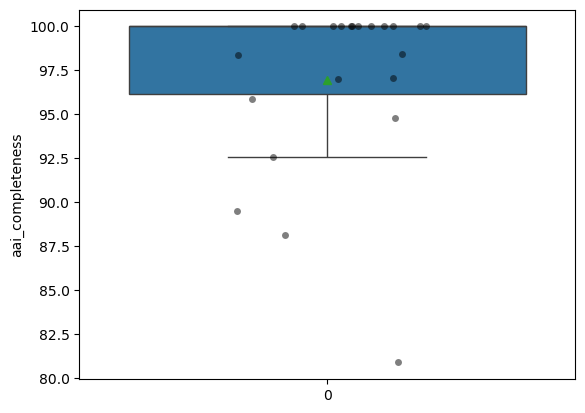

In [2]:
### plot completeness of mVIRs viruses
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=mvirs_merged, x=0, y='aai_completeness', showmeans=True, showfliers=False)
sns.stripplot(data=mvirs_merged, x=0, y='aai_completeness', color='black', alpha=0.5, jitter=0.2)
plt.show()

In [3]:
### Identify all proviruses detected by genomad and checkv
genomad_lst = []
for file in glob.glob('genomad/mvirs/*_genome/*_genome_virus_summary.tsv'):
    genomad = (
        pl.read_csv(file, separator='\t',
            columns=['seq_name', 'length', 'topology', 'coordinates', 'virus_score', 'n_hallmarks', 'taxonomy'])
            .filter(pl.col('topology') == 'Provirus')
            .with_columns([
                (pl.col('seq_name')).alias('provirus_id'),
                (pl.col('seq_name').str.split('|').list[0]).alias('genome_id'),
                (pl.col('coordinates').str.split('-').list[0]).cast(pl.Int64).alias('provirus_start'),
                (pl.col('coordinates').str.split('-').list[-1]).cast(pl.Int64).alias('provirus_stop')
            ])
    )
    if genomad.shape[0] > 0:
        genomad_lst.append(
            genomad
                .filter(
                    (pl.col('virus_score') >= 0.95) &
                    (pl.col('n_hallmarks') > 2)
                )
                .drop(['topology', 'seq_name', 'coordinates'])
        )
    else:
        continue

# concatenate all genomad results
genomad_genome = pl.concat(genomad_lst)


# load checkv results for proviruses in complete genomes
checkv_lst = []
for file in glob.glob('checkv/mvirs/*_genome/*_genome_completeness.tsv.gz'):
    # load checkv genome results
    checkv = (
        pl.read_csv(file, separator='\t',
            ignore_errors=True, columns=['contig_id', 'aai_completeness', 'aai_confidence', 'kmer_freq'])
            .with_columns([
                (pl.col('contig_id').alias('provirus_id')),
                pl.col('aai_completeness').cast(pl.String)
            ])
    )

    if checkv.filter(pl.col('aai_confidence').is_in(['high', 'medium'])).shape[0] > 0:
        checkv_lst.append(
            checkv
                .filter(
                    (pl.col('aai_confidence').is_in(['high', 'medium'])) &
                    (pl.col('kmer_freq') <= 1.5)
                )
                .drop('contig_id', 'kmer_freq')
        )
    else:
        continue

# concatenate all checkv results
checkv_genome = pl.concat(checkv_lst)

# merge all genome dataframes
genome_merged = (
    genomad_genome
        .join(checkv_genome, on='provirus_id',  how='inner', coalesce=True)
        .with_columns([
            pl.col('aai_completeness').cast(pl.Float64)
        ])
)

print("Number of unique provirus ids:", len(set(genome_merged['provirus_id'])))

Number of unique provirus ids: 45


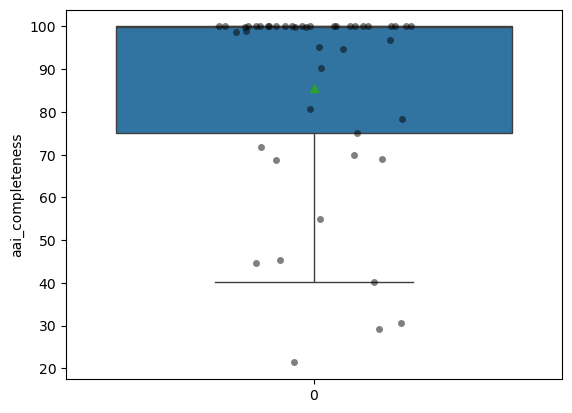

In [4]:
### plot completeness of genomad/checkv proviruses
sns.boxplot(data=genome_merged, x=0, y='aai_completeness', showmeans=True, showfliers=False)
sns.stripplot(data=genome_merged, x=0, y='aai_completeness', color='black', alpha=0.5, jitter=0.2)
plt.show()

In [5]:
### join mvirs and complete genome data
genome_mvirs_merged = (
    mvirs_merged
        .join(genome_merged, on='genome_id', how='full', coalesce=True)
)

In [6]:
### determine which mvirs proviruses and overlap with proviruses detected
genome_mvirs_merged = (
    genome_mvirs_merged
        .with_columns([
            (
                (pl.col('provirus_stop') - pl.col('mvirs_start') > 1000) &
                (pl.col('mvirs_stop') >= pl.col('provirus_start'))
            ).alias('mvirs_overlaps_provirus')
        ])
)

Number of unique mVIRs: 23
Number of mVIRs with overlap: 21


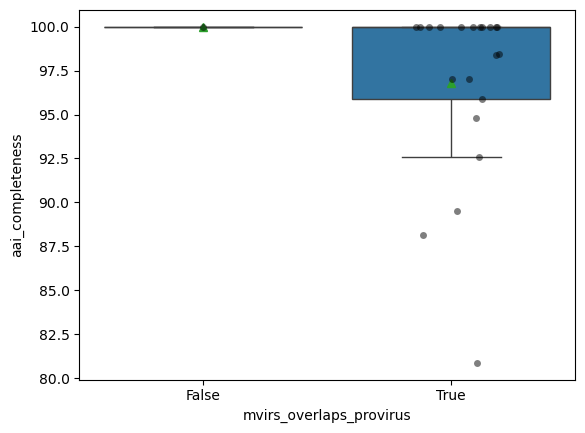

In [7]:
### plot completeness of mVIRs viruses by overlap status
pl.Config.set_tbl_rows(25)

mvirs_plot_prep = (
    genome_mvirs_merged
        .select(
            pl.col('mvirs_id'),
            pl.col('genome_id'),
            pl.col('mvirs_start'),
            pl.col('mvirs_stop'),
            pl.col('aai_completeness'),
            pl.col('n_hallmarks'),
            pl.col('virus_score'),
            pl.col('mvirs_overlaps_provirus')
        )
        # .filter(pl.col('mvirs_id').is_not_null())
        .sort('mvirs_overlaps_provirus', descending=True)
        .group_by('mvirs_id', maintain_order=True).first()
)

print("Number of unique mVIRs:", len(set(mvirs_plot_prep['mvirs_id'])))
print("Number of mVIRs with overlap:", len(set(mvirs_plot_prep.filter(pl.col('mvirs_overlaps_provirus') == True)['mvirs_id'])))


# plot completeness by overlap status
sns.boxplot(data=mvirs_plot_prep, x='mvirs_overlaps_provirus', y='aai_completeness', showmeans=True, showfliers=False)
sns.stripplot(data=mvirs_plot_prep, x='mvirs_overlaps_provirus', y='aai_completeness', color='black', alpha=0.5, jitter=0.2)
plt.show()

Number of unique GIs: 45
Number of GIs with overlap: 19


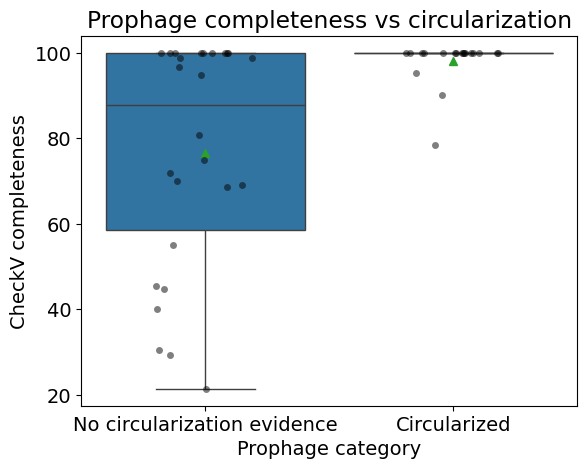

In [10]:
### plot completeness of proviruses by overlap status with mVIRs
genome_plot_prep = (
    genome_mvirs_merged
        .select(
            pl.col('provirus_id'),
            pl.col('genome_id'),
            pl.col('provirus_start'),
            pl.col('provirus_stop'),
            pl.col('aai_completeness_right'),
            pl.col('n_hallmarks_right'),
            pl.col('virus_score_right'),
            pl.col('mvirs_overlaps_provirus')
        )
        .filter(pl.col('provirus_id').is_not_null())
        .sort('mvirs_overlaps_provirus', descending=True)
        .group_by('provirus_id', maintain_order=True).first()
        .with_columns([
            pl.when(pl.col('mvirs_overlaps_provirus') == True)
            .then(pl.lit('Circularized'))
            .otherwise(pl.lit('No circularization evidence'))
            .alias('category')
        ])
)

print("Number of unique GIs:", len(set(genome_plot_prep['provirus_id'])))
print("Number of GIs with overlap:", len(set(genome_plot_prep.filter(pl.col('mvirs_overlaps_provirus') == True)['provirus_id'])))

# plot completeness by tr_type
import matplotlib.pyplot as plt

sns.boxplot(data=genome_plot_prep, x='category', y='aai_completeness_right', showmeans=True, showfliers=False)
sns.stripplot(data=genome_plot_prep, x='category', y='aai_completeness_right', color='black', alpha=0.5, jitter=0.2)
plt.ylabel('CheckV completeness')
plt.xlabel('Prophage category')
plt.title(f'Prophage completeness vs circularization')
# increase size of font
plt.rcParams.update({'font.size': 16})

plt.show()